# <font color="yellow">**Limpieza de datos de DATASETS EPEN**</font>

## <font color="#07F0DB">1.- Unir datasets de manera general y crear la variable "entrenamiento"</font>


In [1]:
#numpy - arreglos, matrices
#pandas - manejo de dataset
#matplotlib - graficas
#seabor - graficas
#glob - Busca archivos que coincidan con un patrón.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob as gl


In [2]:
# Creando al dataset general
carpeta = sorted(gl.glob("/content/*_Trim_*.csv"))

datasets_list = []

for archivo in carpeta:
  dataset =  pd.read_csv(archivo)
  # *dataset.columns[:-1] selecciona todas las columnas excepto la última y a esta se le cambia el nombre
  dataset.columns = [*dataset.columns[:-1], 'factor_expansion']
  datasets_list.append(dataset)

entrenamiento = pd.concat(datasets_list, ignore_index=True)

##<font color="#07F0DB">2.- Verificar el Dataset e identificar columnas y campos vacíos</font>

* ANIO - Año de la encuesta
* MES - Mes de la encuesta
* CONGLOMERADO - Número del conglomerado
* MUESTRA - Nº de Sub Muestra
* SELVIV - Número de selección de la vivienda
* HOGAR - Hogar
* REGION - Región (1. Lima Metropolitana, 2. Resto urbano, 3. Rural)
* LLAVE_PANEL - Código del personal panel
* ESTRATO - Estrato geográfico (1 a 8 según tamaño de la UPM)
* C201 - 201. N° de orden (CÓDIGO DE PERSONA)
* C203 - 203. ¿Cuál es la relación de parentesco con el jefe del hogar?
* C204 - 204. ¿Es miembro del hogar?
* C205 - 205. ¿Se encuentra ausente del hogar 30 días o más?
* C206 - 206. ¿Está presente en el hogar 30 días o más?
* C207 - 207. Sexo
* C208 - 208. ¿Qué edad tiene en años cumplidos?
* C300n - Código de persona (Módulo de Empleo)
* NROINF - Código de informante (Módulo de Empleo)
* C301_DIA - 301. ¿Cuál es la fecha de su nacimiento? - Día
* C301_MES - 301. ¿Cuál es la fecha de su nacimiento? - Mes
* C301_ANIO - 301. ¿Cuál es la fecha de su nacimiento? - Año
* C303 - 303. ¿La semana pasada trabajó al menos 1 hora?
* C304 - 304. Aunque no trabajó la semana pasada, ¿tuvo algún empleo fijo al que próximamente volverá?
* C305 - 305. Aunque no trabajó la semana pasada, ¿tuvo algún negocio propio al que próximamente volverá?
* C306_1 - 306. Actividad semana pasada: ¿Trabajó en negocio propio o de un familiar?
* C306_2 - 306. Actividad semana pasada: ¿Ofreció algún servicio?
* C306_3 - 306. Actividad semana pasada: ¿Hizo algo en casa para vender?
* C306_4 - 306. Actividad semana pasada: ¿Vendió productos de belleza, ropa, joyas, entre otros?
* C306_5 - 306. Actividad semana pasada: ¿Realizó alguna labor artesanal?
* C306_6 - 306. Actividad semana pasada: ¿Hizo prácticas pagadas en un centro de trabajo?
* C306_7 - 306. Actividad semana pasada: ¿Trabajó para un hogar particular?
* C306_8 - 306. Actividad semana pasada: ¿Fabricó algún producto?
* C306_9 - 306. Actividad semana pasada: ¿Realizó labores remuneradas en la chacra o cuidado de animales?
* C306_10 - 306. Actividad semana pasada: ¿Ayudó a un familiar de su hogar, sin remuneración?
* C306_10A - 306. Actividad semana pasada: ¿Ayudó con el empleo de algún miembro de su hogar?
* C306_11 - 306. Actividad semana pasada: ¿Otra?
* C306A - 306A. ¿El informante es productor agrícola y/o pecuario?
* C308_COD - 308. ¿Cuál es la ocupación principal que desempeñó? - Código
* C309_COD - 309. ¿A qué se dedica el negocio/empresa en la que trabajó en su ocupación principal? - Código
* C310 - 310. Categoría de ocupación principal (empleador, independiente, empleado, etc.)
* C311 - 311. En su ocupación principal, ¿Ud. trabajó para:
* C312 - 312. ¿El negocio/empresa está registrado en SUNAT?
* C313 - 313. ¿El negocio/empresa lleva libros contables exigidos por la SUNAT?
* C317 - 317. Número de trabajadores en el negocio/empresa (rangos)
* C317A - 317A. Número exacto de trabajadores en el negocio/empresa
* C318_1 - 318. Horas trabajadas la semana pasada en ocupación principal - Domingo
* C318_2 - 318. Horas trabajadas la semana pasada en ocupación principal - Lunes
* C318_3 - 318. Horas trabajadas la semana pasada en ocupación principal - Martes
* C318_4 - 318. Horas trabajadas la semana pasada en ocupación principal - Miércoles
* C318_5 - 318. Horas trabajadas la semana pasada en ocupación principal - Jueves
* C318_6 - 318. Horas trabajadas la semana pasada en ocupación principal - Viernes
* C318_7 - 318. Horas trabajadas la semana pasada en ocupación principal - Sábado
* C318_T - 318. Total de horas trabajadas la semana pasada en ocupación principal
* C328_T - 328. Total de horas trabajadas la semana pasada en ocupación(es) secundaria(s)
* C330 - 330. En total, ¿cuántas horas trabajó la semana pasada?
* C331 - 331. Normalmente, ¿cuántas horas trabaja a la semana en todas sus ocupaciones?
* C333 - 333. La semana pasada, ¿quería trabajar más horas de las que normalmente trabaja?
* C334 - 334. La semana pasada, ¿estuvo disponible para trabajar más horas?
* P209H - ¿Tuvo la voluntad de trabajar más horas y además estuvo disponible para hacerlo?
* C335 - 335. La semana pasada, ¿estuvo Ud. buscando otro empleo? (Ocupados)
* C338 - 338. En su ocupación principal, ¿a Ud. le pagan: (frecuencia)?
* C339_1 - 339. Ingreso total en ocupación principal (dependiente) - Monto S/.
* C341_T - 341. Valor estimado total de pago en especies en ocupación principal (dependiente)
* C342 - 342. Ganancia neta en el mes anterior en ocupación principal (independiente)
* C344 - 344. Valor estimado de productos para consumo propio en mes anterior (independiente)
* C345_1 - 345. Ingreso total en ocupación(es) secundaria(s) (dependiente) - Monto S/.
* C347_T - 347. Valor estimado total de pago en especies en ocupación secundaria (dependiente)
* C348 - 348. Ganancia neta en el mes anterior en ocupación(es) secundaria(s) (independiente)
* C350 - 350. Valor estimado de productos para consumo propio en ocupación secundaria (independiente)
* C352 - 352. La semana pasada, ¿hizo algo para conseguir trabajo? (Desocupados)
* C353 - 353. ¿Qué estuvo haciendo la semana pasada? (Desocupados)
* C354 - 354. La semana pasada, ¿quería Ud. trabajar?
* C355 - 355. La semana pasada, ¿estuvo disponible para trabajar?
* C356 - 356. ¿Por qué no buscó trabajo?
* C357_I - 357. Gestión más importante para conseguir trabajo la semana pasada
* C358 - 358. ¿Cuántas semanas ha estado buscando trabajo, sin interrupciones?
* C359 - 359. ¿Ha trabajado antes?
* SEGURO1 - Sistema de seguro de salud al cual está afiliado
* C361_1 - 361. ¿Está afiliado a EsSalud?
* C361_2 - 361. ¿Está afiliado a seguro privado de salud?
* C361_3 - 361. ¿Está afiliado a Entidad Prestadora de Salud (EPS)?
* C361_4 - 361. ¿Está afiliado a seguro de FF.AA./Policiales?
* C361_5 - 361. ¿Está afiliado al Seguro Integral de Salud (SIS)?
* C361_6 - 361. ¿Está afiliado a seguro universitario?
* C361_7 - 361. ¿Está afiliado a seguro escolar privado?
* C361_8 - 361. ¿Está afiliado a otro seguro de salud?
* C362_1 - 362. ¿Quién aporta las cuotas? - EsSalud
* C362_2 - 362. ¿Quién aporta las cuotas? - Seguro privado de salud
* C362_3 - 362. ¿Quién aporta las cuotas? - Entidad Prestadora de Salud
* C362_4 - 362. ¿Quién aporta las cuotas? - Seguro FF.AA./Policiales
* C362_5 - 362. ¿Quién aporta las cuotas? - Seguro Integral de Salud (SIS)
* C362_6 - 362. ¿Quién aporta las cuotas? - Seguro universitario
* C362_7 - 362. ¿Quién aporta las cuotas? - Seguro escolar privado
* C362_8 - 362. ¿Quién aporta las cuotas? - Otro seguro
* C364_1 - 364. ¿Está afiliado al Sistema Privado de Pensiones (AFP)?
* C364_2 - 364. ¿Está afiliado al Sistema Nacional de Pensiones Ley 19990?
* C364_3 - 364. ¿Está afiliado al Sistema Nacional de Pensiones Ley 20530 (Cédula Viva)?
* C364_4 - 364. ¿Está afiliado a otro sistema de pensiones?
* C365_1 - 365. ¿Quién aporta las cuotas? - AFP
* C365_2 - 365. ¿Quién aporta las cuotas? - SNP Ley 19990
* C365_3 - 365. ¿Quién aporta las cuotas? - SNP Ley 20530
* C365_4 - 365. ¿Quién aporta las cuotas? - Otro sistema de pensiones
* C366 - 366. Último nivel de estudios aprobado
* C366_1 - 366. Último año de estudios aprobado
* C366_2 - 366. Último grado de estudios aprobado
* C375_1 - 375. Limitación permanente para moverse o caminar / usar brazos o piernas
* C375_2 - 375. Limitación permanente para ver (aun usando anteojos)
* C375_3 - 375. Limitación permanente para hablar o comunicarse
* C375_4 - 375. Limitación permanente para oír (aun usando audífonos)
* C375_5 - 375. Limitación permanente para entender o aprender
* C375_6 - 375. Limitación permanente para relacionarse con los demás
* C376 - 376. Idioma o lengua materna aprendida en la niñez
* C377 - 377. Autoidentificación étnica por costumbres y antepasados
* OCUP300 - Nivel de ocupación / Condición de actividad (ocupado, desocupado, inactivo)
* I339_1 - Ingreso mensual monetario de la actividad principal (dependiente)
* D341_T - Ingreso mensual en especies de la actividad principal (dependiente, valorizado)
* I342 - Ingreso mensual monetario de la actividad principal (independiente)
* D344 - Ingreso mensual en especies de la actividad principal (independiente, valorizado)
* I345_1 - Ingreso mensual monetario de la actividad secundaria (dependiente)
* I348 - Ingreso mensual monetario de la actividad secundaria (independiente)
* D347_T - Ingreso mensual en especies de la actividad secundaria (dependiente, valorizado)
* D350 - Ingreso mensual en especies de la actividad secundaria (independiente, valorizado)
* D351_T - (Mensual) En los últimos 12 meses, recibió algún dinero: Total
* INGTOT - Ingresos totales
* INGTOTP - Ingreso principal mensual
* INGTRABW - Ingreso mensual de ocupación principal y secundaria con ingresos extraordinarios
* RESIDENT - Residente habitual
* whoraT - Hora total de los ocupados
* factor_expansion - Agrupación de datos trimestrales para el cálculo de empleo


In [3]:
# Verificar el dataset
entrenamiento.head(900)

,ANIO,MES,CONGLOMERADO,MUESTRA,SELVIV,HOGAR,REGION,LLAVE_PANEL,ESTRATO,C201,...,I345_1,I348,D347_T,D350,D351_T,INGTOT,INGTOTP,ingtrabw,RESIDENT,factor_expansion
0,2025,1,18325,1,11,1,1,202501183251001111,1.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,355.262372
1,2025,1,18325,1,15,1,1,202501183251001511,1.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,355.262372
2,2025,1,18338,1,43,1,1,202501183381004311,1.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,312.399192
3,2025,1,18338,1,44,1,1,202501183381004411,1.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,346.503640
4,2025,1,18411,1,56,1,1,202501184111005611,1.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,326.591133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,2025,5,49391,1,34,1,1,202402493911003413,1.0,3,...,NaN,NaN,NaN,NaN,NaN,854.0,854.0,854.0,1,415.744858
896,2025,5,49391,1,34,1,1,202402493911003414,1.0,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
897,2025,5,49391,1,34,1,1,202402493911003415,1.0,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,346.677726
898,2025,5,49391,1,32,1,1,202402493911003211,1.0,1,...,NaN,NaN,NaN,NaN,NaN,800.0,800.0,800.0,1,415.744858


In [4]:
# Conocer campos nulos
entrenamiento.isnull()

,ANIO,MES,CONGLOMERADO,MUESTRA,SELVIV,HOGAR,REGION,LLAVE_PANEL,ESTRATO,C201,...,I345_1,I348,D347_T,D350,D351_T,INGTOT,INGTOTP,ingtrabw,RESIDENT,factor_expansion
0,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
4,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,True
1796,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,False,False,False,False
1797,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,False,False,False,False
1798,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,False,True


<Axes: >

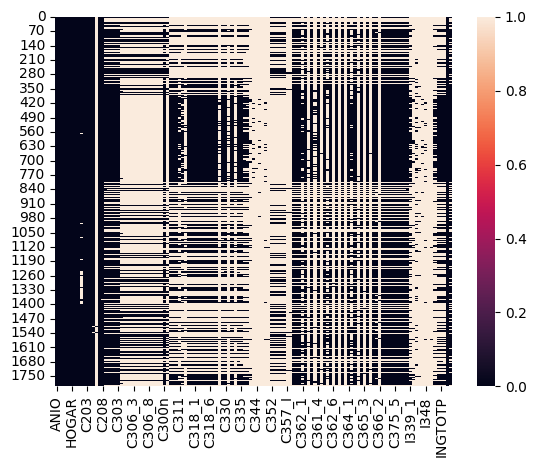

In [5]:
# Ver graficos de valores en blanco
sns.heatmap(entrenamiento.isnull())

In [6]:
# Columnas con valores nulos
col_nulos = []

for col in entrenamiento.columns:
    if entrenamiento[col].isnull().sum() > 0:
        col_nulos.append(col)

print(col_nulos)

['ESTRATO', 'C205', 'C206', 'C208', 'NROINF', 'C301_DIA', 'C301_MES', 'C301_ANIO', 'C303', 'C304', 'C305', 'C306_1', 'C306_2', 'C306_3', 'C306_4', 'C306_5', 'C306_6', 'C306_7', 'C306_8', 'C306_9', 'C306_10', 'C306_10A', 'C306_11', 'C300n', 'C306A', 'C308_COD', 'C309_COD', 'C310', 'C311', 'C312', 'C313', 'C317', 'C317A', 'C318_1', 'C318_2', 'C318_3', 'C318_4', 'C318_5', 'C318_6', 'C318_7', 'C318_T', 'C328_T', 'whoraT', 'C330', 'C331', 'C333', 'C334', 'P209H', 'C335', 'C338', 'C339_1', 'C341_T', 'C342', 'C344', 'C345_1', 'C347_T', 'C348', 'C350', 'C352', 'C353', 'C354', 'C355', 'C356', 'C357_I', 'C358', 'C359', 'SEGURO1', 'C361_1', 'C362_1', 'C361_2', 'C362_2', 'C361_3', 'C362_3', 'C361_4', 'C362_4', 'C361_5', 'C362_5', 'C361_6', 'C362_6', 'C361_7', 'C362_7', 'C361_8', 'C362_8', 'C364_1', 'C365_1', 'C364_2', 'C365_2', 'C364_3', 'C365_3', 'C364_4', 'C365_4', 'C366', 'C366_1', 'C366_2', 'C375_1', 'C375_2', 'C375_3', 'C375_4', 'C375_5', 'C375_6', 'C376', 'C377', 'OCUP300', 'I339_1', 'D341_T

###**<font color="#EFC05B">HEATMAP de Valores Nulos</font>**

/tmp/ipykernel_7124/2306939628.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(resultados_ordenado.values()), y=list(resultados_ordenado.keys()), palette='Reds_r')


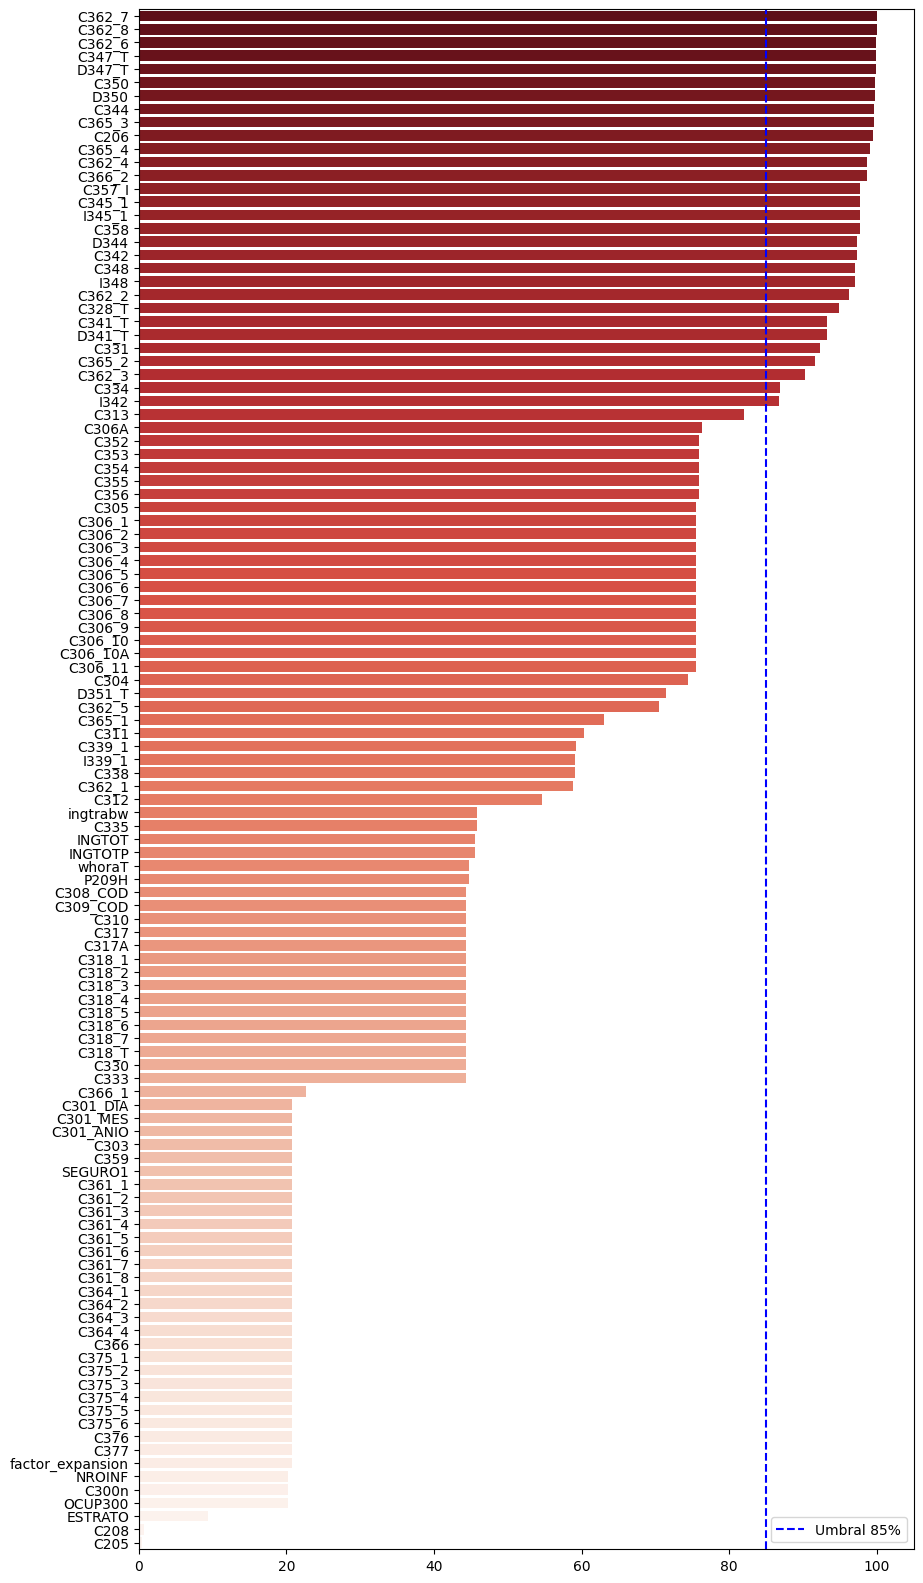

In [7]:
# Verificar el porcentaje de valores nulos en las columnas con valores nulos
resultados = {}

for col in entrenamiento.columns:
    nulos = entrenamiento[col].isnull().sum()
    if nulos > 0:
        resultados[col] = (nulos / len(entrenamiento)) * 100

# Ordenar por porcentaje de mayor a menor
resultados_ordenado = {}

for col in sorted(resultados, key=resultados.get, reverse=True):
    resultados_ordenado[col] = resultados[col]

# Grafico
plt.figure(figsize=(10, 20))
sns.barplot(x=list(resultados_ordenado.values()), y=list(resultados_ordenado.keys()), palette='Reds_r')
plt.axvline(x=85, color='blue', linestyle='--', label='Umbral 85%')
plt.legend()
plt.show()


##<font color="#07F0DB">3.- Eliminamos las columnas vacias al 85%</font>

In [8]:
# Eliminar columnas con más del 85% de nulos
# Primero identificamos las columnas a eliminar
columnas_eliminadas = []

for col in entrenamiento.columns:
    nulos = entrenamiento[col].isnull().sum()
    porcentaje = (nulos / len(entrenamiento)) * 100
    if porcentaje > 85:
        columnas_eliminadas.append(col)

# Luego las eliminas todas de una vez
entrenamiento.drop(columnas_eliminadas, axis=1, inplace=True)

print(f"Columnas eliminadas: {len(columnas_eliminadas)}")
print(f"Columnas restantes: {entrenamiento.shape[1]}")


Columnas eliminadas: 30
Columnas restantes: 99


<Axes: >

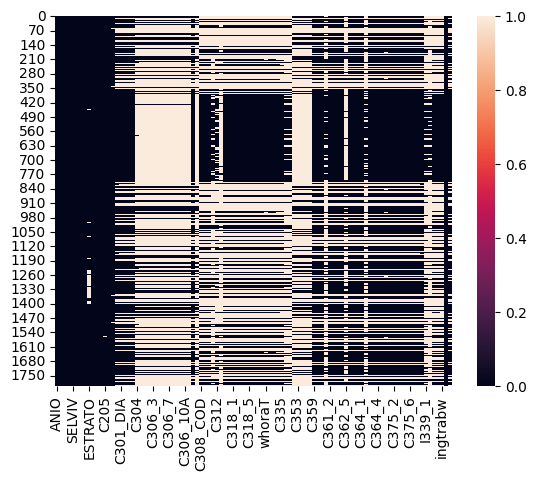

In [9]:
# Resultado de eliminar columnas innecesarias
sns.heatmap(entrenamiento.isnull())

In [10]:
# Verificar el porcentaje de valores nulos en las columnas con valores nulos
resultados = []

for col in entrenamiento.columns:
    nulos = entrenamiento[col].isnull().sum()
    if nulos > 0:
        porcentaje = (nulos / len(entrenamiento)) * 100
        resultados.append((porcentaje, col))

resultados.sort(reverse= True)

for porcentaje, col in resultados:
    print(f"{col}: ({round(porcentaje,2)}%)")

C313: (82.0%)
C306A: (76.33%)
C356: (75.89%)
C355: (75.89%)
C354: (75.89%)
C353: (75.89%)
C352: (75.89%)
C306_9: (75.56%)
C306_8: (75.56%)
C306_7: (75.56%)
C306_6: (75.56%)
C306_5: (75.56%)
C306_4: (75.56%)
C306_3: (75.56%)
C306_2: (75.56%)
C306_11: (75.56%)
C306_10A: (75.56%)
C306_10: (75.56%)
C306_1: (75.56%)
C305: (75.56%)
C304: (74.39%)
D351_T: (71.39%)
C362_5: (70.44%)
C365_1: (63.06%)
C311: (60.28%)
C339_1: (59.22%)
I339_1: (59.11%)
C338: (59.06%)
C362_1: (58.83%)
C312: (54.61%)
ingtrabw: (45.83%)
C335: (45.78%)
INGTOTP: (45.5%)
INGTOT: (45.5%)
whoraT: (44.78%)
P209H: (44.78%)
C333: (44.39%)
C330: (44.39%)
C318_T: (44.39%)
C318_7: (44.39%)
C318_6: (44.39%)
C318_5: (44.39%)
C318_4: (44.39%)
C318_3: (44.39%)
C318_2: (44.39%)
C318_1: (44.39%)
C317A: (44.39%)
C317: (44.39%)
C310: (44.39%)
C309_COD: (44.39%)
C308_COD: (44.39%)
C366_1: (22.61%)
factor_expansion: (20.72%)
SEGURO1: (20.72%)
C377: (20.72%)
C376: (20.72%)
C375_6: (20.72%)
C375_5: (20.72%)
C375_4: (20.72%)
C375_3: (20.72%)


##<font color="#07F0DB">4.- Eliminar colummnas sin relación a nuestro a dato a analizar</font>

El dato que se analizara sera ingreso

In [11]:
# Filtrar solo personas ocupadas con ingreso
entrenamiento = entrenamiento[entrenamiento['OCUP300'] == 1]
entrenamiento = entrenamiento[entrenamiento['INGTOT'].notnull()]

print("Filas tras filtrar ocupados: ", len(entrenamiento))

Filas tras filtrar ocupados:  981


In [12]:
columnas_innecesarias = [
    # Códigos administrativos de la encuesta (no predicen ingreso)
    'ANIO', 'MES', 'CONGLOMERADO', 'MUESTRA', 'SELVIV', 'HOGAR',
    'LLAVE_PANEL', 'C201', 'C203', 'C204', 'C206',
    'C300n', 'NROINF',

    # Fecha de nacimiento (tenemos edad en C208)
    'C301_DIA', 'C301_MES', 'C301_ANIO',

    # Solo para quienes NO trabajaron
    'C313', 'C306A', 'C304', 'C305',
    'C306_1', 'C306_2', 'C306_3', 'C306_4', 'C306_5',
    'C306_6', 'C306_7', 'C306_8', 'C306_9', 'C306_10',
    'C306_10A', 'C306_11',

    # Solo para desocupados
    'C352', 'C353', 'C354', 'C355', 'C356',

    # Códigos de ocupación (muy específicos, no generalizan)
    'C309_COD', 'C308_COD',

    # Número exacto de trabajadores (tenemos rango en C317)
    'C317A',

    # Año de estudios (tenemos nivel en C366)
    'C366_1',

    # Ingresos redundantes con INGTOT
    'D351_T', 'ingtrabw', 'INGTOTP',
    'C339_1', 'I339_1',

    # Quién paga seguros (no predice ingreso)
    'C362_5', 'C365_1', 'C362_1',

    # Seguros específicos con muy pocos afiliados
    'C361_2', 'C361_3', 'C361_4',
    'C361_6', 'C361_7', 'C361_8',
    'C364_2', 'C364_3', 'C364_4',

    # Horas por día individual (tenemos total en C318_T y whoraT)
    'C318_1', 'C318_2', 'C318_3',
    'C318_4', 'C318_5', 'C318_6', 'C318_7',

    # No relevantes para predecir ingreso
    'C303',    # ya filtramos ocupados
    'C330',    # horas normales semanales
    'C333',    # quería trabajar más horas
    'P209H',   # disponible para trabajar más
    'C335',    # buscó otro trabajo
    'OCUP300', # ya filtramos ocupados
    'RESIDENT',# residente habitual
    'factor_expansion', # peso estadístico, no predice ingreso
]

entrenamiento = entrenamiento.drop(columnas_innecesarias, axis=1, errors='ignore')
print(f"Columnas restantes: {entrenamiento.shape[1]}")

Columnas restantes: 27


<Axes: >

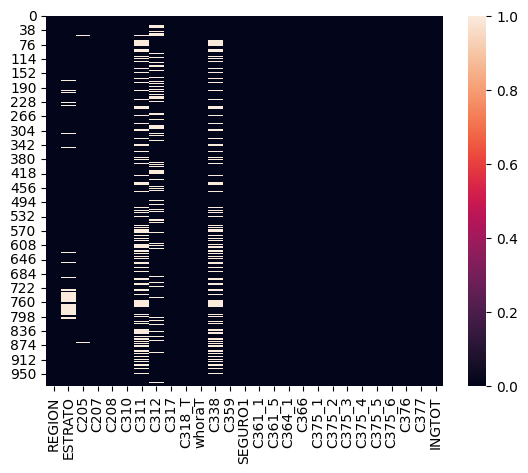

In [13]:
# Resultado de eliminar columnas innecesarias
entrenamiento = entrenamiento.reset_index(drop=True)
sns.heatmap(entrenamiento.isnull())

In [14]:
# Verificar el porcentaje de valores nulos en las columnas con valores nulos
resultados = []

for col in entrenamiento.columns:
    nulos = entrenamiento[col].isnull().sum()
    if nulos > 0:
        porcentaje = (nulos / len(entrenamiento)) * 100
        resultados.append((porcentaje, col))

resultados.sort(reverse= True)

for porcentaje, col in resultados:
    print(f"{col}: ({round(porcentaje,2)}%)")

C311: (27.22%)
C338: (24.97%)
C312: (18.65%)
ESTRATO: (8.97%)
C205: (0.31%)


##<font color="#07F0DB">5.- Imputación</font>

###<font color="#BAACDE">**ViolinPlot**</font>

/tmp/ipykernel_7124/2683124410.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='C311', y='INGTOT', data=entrenamiento, palette='muted')


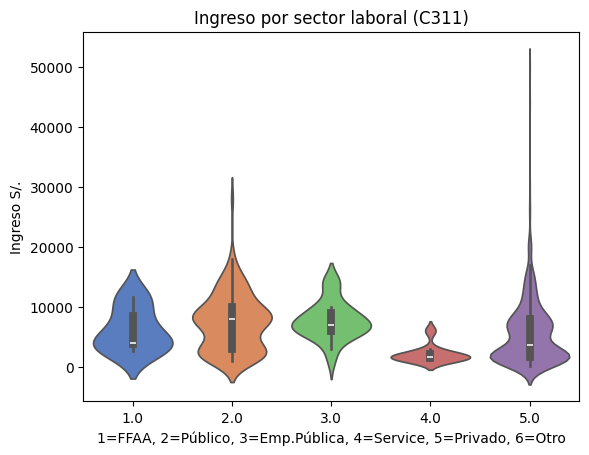

In [15]:
# Grafico violin C311 vs INGTOT
sns.violinplot(x='C311', y='INGTOT', data=entrenamiento, palette='muted')
plt.title('Ingreso por sector laboral (C311)')
plt.xlabel('1=FFAA, 2=Público, 3=Emp.Pública, 4=Service, 5=Privado, 6=Otro')
plt.ylabel('Ingreso S/.')
plt.show()

###<font color="#BAACDE">**BarPlot**</font>

/tmp/ipykernel_7124/134248482.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='C338', y='INGTOT', data=entrenamiento, palette='Blues')


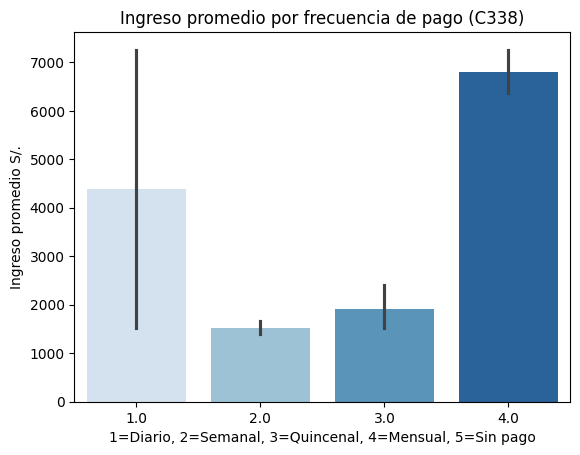

In [16]:
# C338 - Frecuencia de pago vs INGTOT
sns.barplot(x='C338', y='INGTOT', data=entrenamiento, palette='Blues')
plt.title('Ingreso promedio por frecuencia de pago (C338)')
plt.xlabel('1=Diario, 2=Semanal, 3=Quincenal, 4=Mensual, 5=Sin pago')
plt.ylabel('Ingreso promedio S/.')
plt.show()

###<font color="#BAACDE">**PointPlot**</font>

/tmp/ipykernel_7124/431691702.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(x='C312', y='INGTOT', data=entrenamiento, palette='Reds')


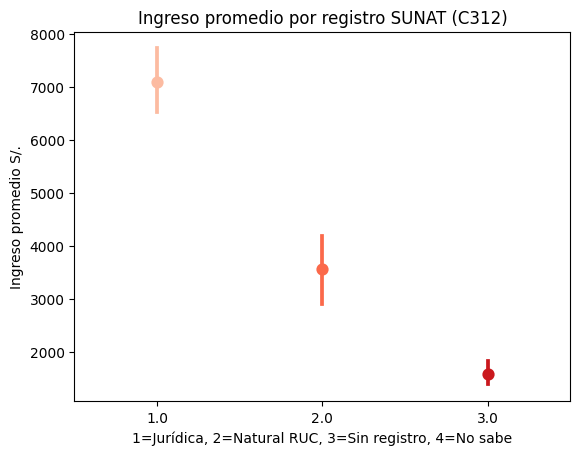

In [17]:
# C312 - Registro SUNAT vs INGTOT
sns.pointplot(x='C312', y='INGTOT', data=entrenamiento, palette='Reds')
plt.title('Ingreso promedio por registro SUNAT (C312)')
plt.xlabel('1=Jurídica, 2=Natural RUC, 3=Sin registro, 4=No sabe')
plt.ylabel('Ingreso promedio S/.')
plt.show()

###<font color="#BAACDE">**BoxenPlot**</font>

/tmp/ipykernel_7124/552946284.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='ESTRATO', y='INGTOT', data=entrenamiento, palette='coolwarm')


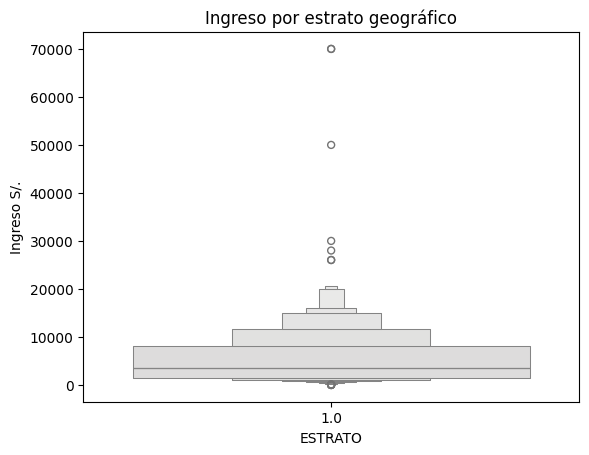

In [18]:
# ESTRATO vs INGTOT
sns.boxenplot(x='ESTRATO', y='INGTOT', data=entrenamiento, palette='coolwarm')
plt.title('Ingreso por estrato geográfico')
plt.ylabel('Ingreso S/.')
plt.show()

###<font color="#BAACDE">**Boxplot**</font>

/tmp/ipykernel_7124/2175203935.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='C205', y='INGTOT', data=entrenamiento, palette=['#FF69B4', '#1E90FF'])
/tmp/ipykernel_7124/2175203935.py:1: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(x='C205', y='INGTOT', data=entrenamiento, palette=['#FF69B4', '#1E90FF'])


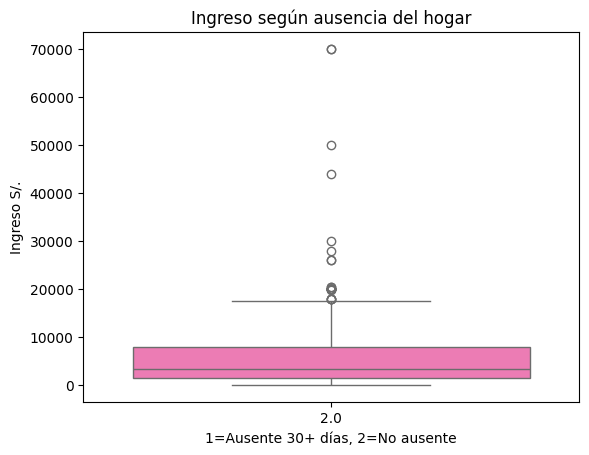

In [19]:
sns.boxplot(x='C205', y='INGTOT', data=entrenamiento, palette=['#FF69B4', '#1E90FF'])
plt.title('Ingreso según ausencia del hogar')
plt.xlabel('1=Ausente 30+ días, 2=No ausente')
plt.ylabel('Ingreso S/.')
plt.show()

In [20]:
# Creando función para rellenar el dataset
def dataset_moda(df, columnas):
    for col in columnas:
        moda = df[col].mode()[0]
        df[col] = df[col].fillna(moda)
    return df

In [21]:
columnas_imputar = ['C311', 'C338', 'C312', 'ESTRATO', 'C205']
entrenamiento = dataset_moda(entrenamiento, columnas_imputar)

##<font color="#07F0DB">6.- Resultado Final</font>

<Axes: >

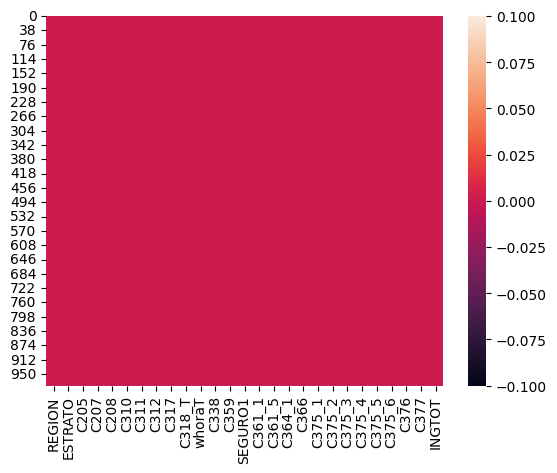

In [22]:
sns.heatmap(entrenamiento.isnull())

**7. ENTRENAMIENTO DE DATASET**

In [23]:
# Verificar el dataset limpio y sus columnas disponibles
print("Columnas disponibles en el dataset:")
print(entrenamiento.columns)
print(f"\nVerificación de valores nulos:")
print(entrenamiento.isnull().sum())

Columnas disponibles en el dataset:
Index(['REGION', 'ESTRATO', 'C205', 'C207', 'C208', 'C310', 'C311', 'C312',
       'C317', 'C318_T', 'whoraT', 'C338', 'C359', 'SEGURO1', 'C361_1',
       'C361_5', 'C364_1', 'C366', 'C375_1', 'C375_2', 'C375_3', 'C375_4',
       'C375_5', 'C375_6', 'C376', 'C377', 'INGTOT'],
      dtype='object')

Verificación de valores nulos:
REGION     0
ESTRATO    0
C205       0
C207       0
C208       0
C310       0
C311       0
C312       0
C317       0
C318_T     0
whoraT     0
C338       0
C359       0
SEGURO1    0
C361_1     0
C361_5     0
C364_1     0
C366       0
C375_1     0
C375_2     0
C375_3     0
C375_4     0
C375_5     0
C375_6     0
C376       0
C377       0
INGTOT     0
dtype: int64


In [24]:
# Separamos la variable objetivo "Y" de la variables predictivas "X"
# "Y" contiene los valores de ingreso que queremos predecir que en este caso es INGTOT (ingresos totales)
y = entrenamiento['INGTOT']

In [25]:
# "X" contiene todas las características excepto la variable objetivo "Y"
# Eliminamos la columna INGTOT para tener solo las variables predictivas
X = entrenamiento.drop('INGTOT', axis=1)

In [26]:
print("\nDefinición de Variables X , Y")
print(f"Variable Objetivo (y) - INGTOT:")
print(f"  Dimension: {y.shape}")
print(f"\nVariables Predictiva (X):")
print(f"  Dimension: {X.shape}")


Definición de Variables X , Y
Variable Objetivo (y) - INGTOT:
  Dimension: (981,)

Variables Predictiva (X):
  Dimension: (981, 26)


In [27]:
from sklearn.model_selection import train_test_split

In [28]:
# train_test_split divide los datos en 80% entrenamiento y 20% prueba
# random_state=42 asegura reproducibilidad de los resultados
# Dividir datos: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [29]:
print("\nDimensiones de las Variables Predictivas")
print("X_train: ", X_train.shape) #Imprime el 80% de los datos
print("X_test (prueba): ", X_test.shape) #Imprime el 20% de los datos
print("\nDimensiones de las Variable Objetivo")
print("y_train: ", y_train.shape) #Imprime los valores de ingreso para entrenamiento
print("y_test (prueba): ", y_test.shape) #Imprime los valores de ingreso para prueba


Dimensiones de las Variables Predictivas
X_train:  (784, 26)
X_test (prueba):  (197, 26)

Dimensiones de las Variable Objetivo
y_train:  (784,)
y_test (prueba):  (197,)


In [30]:
from xgboost import XGBRegressor

In [31]:
# Al usar el modelo de XGBoost se necesitan los siguientes parámetros principales en su estructura:
#   n_estimators: son los números de árboles (o modelos base)
#   max_depth: la profundidad máxima de cada árbol
#   learning_rate: la tasa de aprendizaje (eta)
#   subsample: la fracción de muestras para entrenar cada árbol
#   colsample_bytree: la fracción de características (columnas) para cada árbol
#   random_state: seed para reproducibilidad
modelo_xgb = XGBRegressor(
    n_estimators=100,        # Crea 100 árboles (o modelos base)
    max_depth=5,             # Cada árbol tiene máximo 5 niveles de profundidad
    learning_rate=0.1,       # Tasa de aprendizaje (0.1 es moderada, más bajo es igual a más lento pero potencialmente mejor)
    subsample=0.8,           # Se usa el 80% de las muestras en cada árbol
    colsample_bytree=0.8,    # Se usa el 80% de las características (columnas) en cada árbol
    objective='reg:squarederror',  # Objetivo: regresión (minimizar error cuadrático)
    random_state=42          # Sirve para reproducibilidad
)

In [32]:
# Entrenamiento del modelo con los datos de entrenamiento
print("\nEntrenamiento del Modelo de XGBoost")
modelo_xgb.fit(X_train, y_train) #Entrena el modelo con X_train (características) e y_train (ingresos reales)
print("Entrenamiento Completado")


Entrenamiento del Modelo de XGBoost
Entrenamiento Completado


**EVALUACIÓN DEL MODELO XGBOOST**

In [33]:
# Se realizan las predicciones en el conjunto de prueba
# El método predict() devuelve los valores predichos para cada muestra en X_test
y_pred = modelo_xgb.predict(X_test)

In [34]:
print("\nPredicciones con el Modelo XGBoost")
print("Número de predicciones:", len(y_pred))
print("\nPrimeras 10 predicciones vs Valores reales:")
comparacion = pd.DataFrame({
    'Valor Real': y_test.iloc[:10].values,
    'Predicción': y_pred[:10],                           #Contiene las predicciones del modelo para X_test
    'Error': y_test.iloc[:10].values - y_pred[:10]
})
print(comparacion.to_string(index=False))


Predicciones con el Modelo XGBoost
Número de predicciones: 197

Primeras 10 predicciones vs Valores reales:
 Valor Real   Predicción        Error
     1400.0  3160.977539 -1760.977539
     6500.0 10791.867188 -4291.867188
     2215.0  2006.023926   208.976074
     1299.0  1907.990723  -608.990723
     3388.0  4023.733887  -635.733887
     1299.0  1232.376221    66.623779
     5000.0  7495.041992 -2495.041992
     1860.0  3910.465332 -2050.465332
    10000.0  4651.562500  5348.437500
     7700.0  5910.248535  1789.751465


El análisis para la primera fila es el siguiente:
- El ingreso real fue S/. 20,000
- El modelo predijo S/. 17,191.81
- El error fue +S/. 2,808.19 (quiere decir que el modelo subestimó en 2,808 soles)

Esto quiere decir que el modelo se equivocó por abajo, predijo menos de lo real

El análisis para la segunda fila es el siguiente:
- El ingreso real fue S/. 732
- El modelo predijo S/. 3,126.64
- El error fue -S/. 2,394.64 (el modelo sobrestimó en 2,394 soles)

Esto quiere decir que el modelo se equivocó por arriba, predijo más de lo real

**CÁLCULO DE LAS MÉTRICAS DE DESEMPEÑO**

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [36]:
# Calcular las métricas de regresión

# MAE (Mean Absolute Error) - Error Absoluto Medio
# Calcula El promedio de cuánto se equivocó el modelo en soles (sin importar si fue más o menos)
mae = mean_absolute_error(y_test, y_pred)

# MSE (Mean Squared Error) - Error Cuadrático Medio
# El promedio de los errores elevados al cuadrado. Penaliza errores grandes más que errores pequeños
mse = mean_squared_error(y_test, y_pred)

# RMSE (Root Mean Squared Error) - Raíz del Error Cuadrático Medio (MSE)
# Su función es como si buscaramos "arreglar" el MSE para que vuelva a estar en unidades de soles
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R² Score - Coeficiente de Determinación
# Indica qué proporción de la varianza en y es explicada por el modelo
# Rango: 0 a 1 (1 es perfecto). Cuanto más alto sea su valor, mejor será el modelo.
r2 = r2_score(y_test, y_pred)

In [37]:
print("\nCálculo de las Métricas de Desempeño")
print(f"MAE (Error Absoluto Medio):     S/. {mae:.2f}")
print(f"MSE (Error Cuadrático Medio):   S/. {mse:.2f}")
print(f"RMSE (Raíz del Error Cuadrático): S/. {rmse:.2f}")
print(f"R² Score (Coeficiente R²):      {r2:.4f} ({r2*100:.2f}%)")
print(f"\nInterpretación: El modelo explica el {r2*100:.2f}% de la variabilidad en los ingresos")


Cálculo de las Métricas de Desempeño
MAE (Error Absoluto Medio):     S/. 1733.38
MSE (Error Cuadrático Medio):   S/. 6388818.38
RMSE (Raíz del Error Cuadrático): S/. 2527.61
R² Score (Coeficiente R²):      0.8567 (85.67%)

Interpretación: El modelo explica el 85.67% de la variabilidad en los ingresos


**Conclusiones del cálculo de las métricas de desempeño**
- MAE: El modelo se equivoca en promedio S/. 1,866.88 en cada predicción
- RMSE: El modelo se equivoca en promedio S/. 2,959.95 considerando errores grandes. Se cumple la propiedad RMSE > MAE. Esto significa que hay algunos errores muy grandes que elevan el promedio. Cuanto más lejos esté RMSE de MAE, más errores grandes hay
- R²: Se obtuvo un 80.66%. Esto significa que el modelo explica el 80.66% de la variabilidad en los ingresos y además está capturando bien los patrones

In [38]:
import matplotlib.pyplot as plt

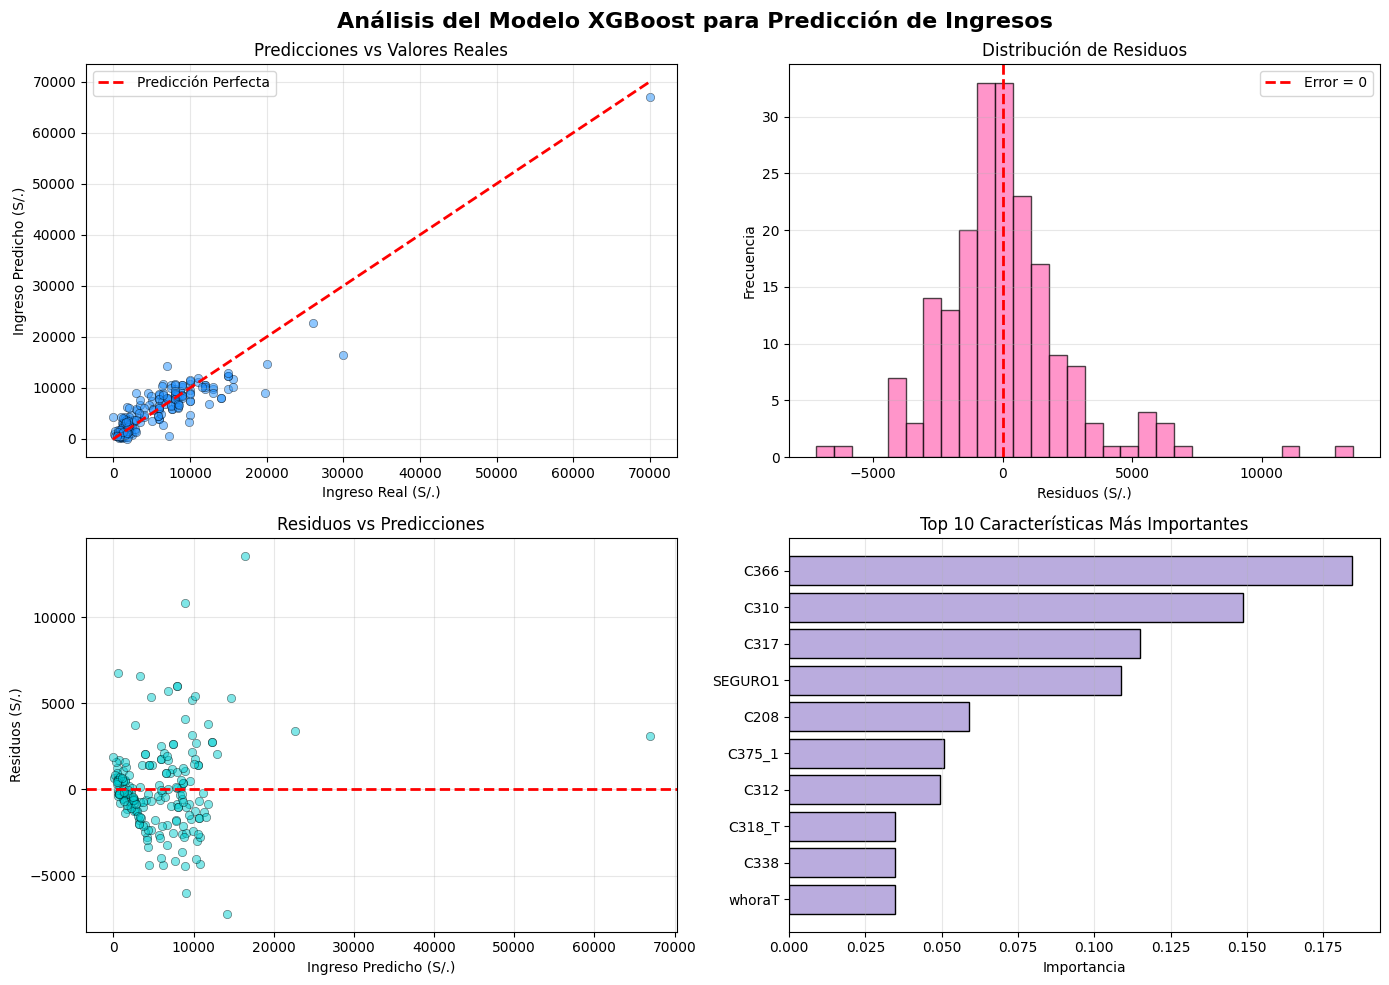

In [39]:
# Crear figura con 4 subgráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis del Modelo XGBoost para Predicción de Ingresos',
             fontsize=16, fontweight='bold')

# Gráfico 1: Predicciones vs Valores Reales
ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred, alpha=0.5, color='#1E90FF', edgecolors='black', linewidth=0.5)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción Perfecta')
ax1.set_xlabel('Ingreso Real (S/.)')
ax1.set_ylabel('Ingreso Predicho (S/.)')
ax1.set_title('Predicciones vs Valores Reales')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Distribución de Residuos
ax2 = axes[0, 1]
residuos = y_test - y_pred
ax2.hist(residuos, bins=30, color='#FF69B4', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error = 0')
ax2.set_xlabel('Residuos (S/.)')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de Residuos')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Gráfico 3: Residuos vs Predicciones
ax3 = axes[1, 0]
ax3.scatter(y_pred, residuos, alpha=0.5, color='#00CED1', edgecolors='black', linewidth=0.5)
ax3.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Ingreso Predicho (S/.)')
ax3.set_ylabel('Residuos (S/.)')
ax3.set_title('Residuos vs Predicciones')
ax3.grid(True, alpha=0.3)

# Gráfico 4: Importancia de Características
ax4 = axes[1, 1]
feature_importance = modelo_xgb.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

top_features = importance_df.head(10)
ax4.barh(range(len(top_features)), top_features['Importance'], color='#BAACDE', edgecolor='black')
ax4.set_yticks(range(len(top_features)))
ax4.set_yticklabels(top_features['Feature'])
ax4.set_xlabel('Importancia')
ax4.set_title('Top 10 Características Más Importantes')
ax4.invert_yaxis()
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [40]:
# Ver top 10 características
importance_df.head(10)

,Feature,Importance
17,C366,0.184460
5,C310,0.148706
8,C317,0.115124
13,SEGURO1,0.108788
4,C208,0.058877
18,C375_1,0.050677
7,C312,0.049470
9,C318_T,0.034830
11,C338,0.034740
10,whoraT,0.034629


**INTERPRETACIÓN DE LA TABLA DE CARACTERÍSTICAS:**

Para la primera fila:
- C366 con importancia 0.206365 (20.64%)
  - Es la variable MÁS importante
  - Contribuye el 20.64% a las predicciones
  - El modelo "confía mucho" en C366 para predecir ingresos

Para la segunda fila:
- C310 con importancia 0.121899 (12.19%)
  - Segunda más importante
  - Contribuye el 12.19%

Para la tercera fila:
- SEGURO1 con importancia 0.120428 (12.04%)
  - Tercera más importante
  - Contribuye el 12.04%

Para la última fila:
- C311 con importancia 0.035301 (3.53%)
  - Décima más importante
  - Contribuye solo el 3.53%

Se puede concluir en que las 3 variables más importantes en nuestro modelo son "C366", "C319" Y "SEGURO1". Juntas llegan a explicar el 44.87% de las predicciones. Estas 10 variables llegan a sumar aproximadamente el 75%-80% de las predicciones generadas, las demás visbibles solo alcanzan el 20%-30%

**MATRIZ DE CONFUSIÓN**


In [41]:
# Convertir los ingresos reales en tres categorías:
# Bajo, Medio y Alto utilizando terciles.

y_test_cat = pd.qcut(
    y_test,
    q=3,
    labels=["Bajo", "Medio", "Alto"]
)

# Convertir las predicciones en las mismas categorías
y_pred_cat = pd.qcut(
    y_pred,
    q=3,
    labels=["Bajo", "Medio", "Alto"]
)

print("Conversión de ingresos a categorías realizada correctamente.")

Conversión de ingresos a categorías realizada correctamente.


In [42]:
# Importamos las librerias para graficar

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Construcción de la matriz de confusión
matriz = confusion_matrix(
    y_test_cat,
    y_pred_cat
)

print(matriz)

[[51  0 15]
 [ 0 50 16]
 [15 16 34]]


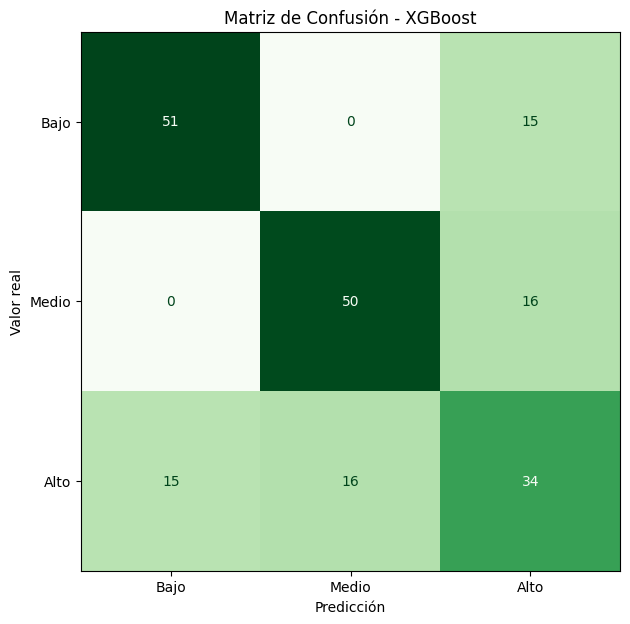

In [43]:
# Visualización de la matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Bajo", "Medio", "Alto"]
)

fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(
    cmap="Greens",
    ax=ax,
    colorbar=False
)

plt.title("Matriz de Confusión - XGBoost")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

**RESUMEN FINAL**

In [44]:
print(f"R² Score: {r2*100:.2f}%")
print(f"MAE: S/. {mae:.2f}")
print(f"RMSE: S/. {rmse:.2f}")

R² Score: 85.67%
MAE: S/. 1733.38
RMSE: S/. 2527.61




El modelo explica el 80.66% de la variabilidad de ingresos con un error promedio de S/. 1,866.88 considerando errores grandes, se equivoca en S/. 2,959.95"

# Importanción de modelo

In [48]:
modelo_xgb.save_model('modelo_ingresos.json')

import json
columnas = X.columns.tolist()
with open('columnas_modelo.json', 'w') as f:
    json.dump(columnas, f)

from google.colab import files
files.download('modelo_ingresos.json')
files.download('columnas_modelo.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>